# Classic models (MIDI) — vodič kroz notebook

Dakle, u ovoj svesci cemo pokusati nad istim podacima da isprobamo razne klasicne modele, s tim sto cemo sada umjesto atributa koje smo ranije koristili koristiti MIDI anotacije.

Posto ovaj pristup zahtijeva znatno manje pretprocesiranje podataka u odnosu na prethodni (izvodjenje atributa iz cistog audio signala), stoga ce ovaj pristup ce biti mnogo brzi.

Sto se tice evaluacije modela i dalje se nista ne mijenja, i dalje u slucaju nekonfigurabilnih modela koristimo unakrsnu validaciju, a za konfigurabilne koristimo unakrsnu validaciju za biranje najboljeg parametra, a ugnjezdjenu unakrsnu validaciju kako bi dali nepristrasnu ocjenu konacnog modela.

In [25]:
%load_ext autoreload
%autoreload 2

import sys
sys.path.insert(0, "..")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Ucitavanje podataka

## Priprema metapodataka


In [26]:
import numpy as np
import pandas as pd

from src.features.dataset import load_metadata
from src.utils.paths import AUDIO_DIR

metadata_filtered = load_metadata()

In [27]:
print(
    metadata_filtered.groupby("composer")["work_id"]
    .nunique()
    .sort_values()
)

composer
Brahms        8
Schubert      9
Mozart       11
Bach         30
Beethoven    55
Name: work_id, dtype: int64


---

## Group-aware evaluacija

Deklarisanje stratified group k folda i unutrasnjeg i spoljasnjeg

In [28]:
from sklearn import metrics
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

from src.model.evaluation import make_sample_weights, majority_vote_prediction
from src.model.classical_model import run_classical_train_pipeline

sgkf = StratifiedGroupKFold(
    n_splits=4,
    shuffle=True,
    random_state=42
)

sgkf_outer = StratifiedGroupKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

---

# MIDI model

Svaka nota u MusicNet anotacijama ima visinu, instrument, tačan onset/offset i trajanje u otkucajima.
`extract_midi_features` (u `midi.py`) iz toga računa gustinu nota, melodijski kontur (interval mean/std,
udio uzlaznih/silaznih/ponovljenih koraka), histogram tonskih klasa, histogram instrumenata (11 fiksnih GM
programa u MusicNet-u), on-beat/off-beat omjer i raspon akorada.

In [29]:
from src.features.midi import make_midi_dataset

X_midi, y_midi, groups_midi = make_midi_dataset(metadata_filtered, AUDIO_DIR)

Processing MIDI labels:  25%|██▍       | 74/302 [00:19<02:26,  1.55it/s]c:\Users\marko.vucic_ominimo\Desktop\music-classifier\.venv\Lib\site-packages\pretty_midi\pretty_midi.py:122: RuntimeWarning: Tempo, Key or Time signature change events found on non-zero tracks.  This is not a valid type 0 or type 1 MIDI file.  Tempo, Key or Time Signature may be wrong.
  warnings.warn(
Processing MIDI labels:  25%|██▍       | 75/302 [00:20<02:24,  1.57it/s]c:\Users\marko.vucic_ominimo\Desktop\music-classifier\.venv\Lib\site-packages\pretty_midi\pretty_midi.py:122: RuntimeWarning: Tempo, Key or Time signature change events found on non-zero tracks.  This is not a valid type 0 or type 1 MIDI file.  Tempo, Key or Time Signature may be wrong.
  warnings.warn(
Processing MIDI labels:  25%|██▌       | 76/302 [00:20<02:08,  1.76it/s]c:\Users\marko.vucic_ominimo\Desktop\music-classifier\.venv\Lib\site-packages\pretty_midi\pretty_midi.py:122: RuntimeWarning: Tempo, Key or Time signature change events found

Fold 1:

n_estimators=500, max_depth=20, min_samples_leaf=1: accuracy=0.7693, macro_f1=0.6079
n_estimators=500, max_depth=20, min_samples_leaf=3: accuracy=0.7475, macro_f1=0.6015
n_estimators=500, max_depth=20, min_samples_leaf=5: accuracy=0.7362, macro_f1=0.6004

Best params: {'n_estimators': 500, 'max_depth': 20, 'min_samples_leaf': 1}
Best accuracy: 0.7692687747035574
Best macro F1: 0.6078794013004539 

outer fold: best_params={'n_estimators': 500, 'max_depth': 20, 'min_samples_leaf': 1} -> accuracy=0.8182, macro_f1=0.7406

Fold 2:

n_estimators=500, max_depth=20, min_samples_leaf=1: accuracy=0.7678, macro_f1=0.5774
n_estimators=500, max_depth=20, min_samples_leaf=3: accuracy=0.7673, macro_f1=0.6280
n_estimators=500, max_depth=20, min_samples_leaf=5: accuracy=0.7673, macro_f1=0.6736

Best params: {'n_estimators': 500, 'max_depth': 20, 'min_samples_leaf': 5}
Best accuracy: 0.7672924901185771
Best macro F1: 0.6736431019960432 

outer fold: best_params={'n_estimators': 500, 'max_depth'

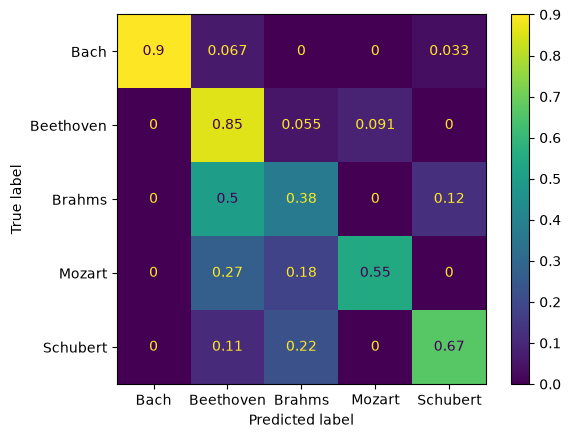

NameError: name 'save_classical_model' is not defined

In [30]:
rfc_model = RandomForestClassifier(
    max_features="sqrt",
    random_state=42,
    n_jobs=-1
)

param_grid = {
    "n_estimators": [500], # tried [50, 100, 300] but models statistically improve with more estimators with ceiling at ~500
    "max_depth": [20], # tried 30 as well - but 20 is ceiling here
    "min_samples_leaf": [1, 3, 5] # regularization
}

_ = run_classical_train_pipeline(
    "random_forest_midi",
    X=X_midi,
    y=y_midi, 
    groups=groups_midi, 
    model=rfc_model, 
    cv=sgkf, 
    param_grid=param_grid, 
    outer_cv=sgkf_outer
)


## ------ SVM Model -------------------------------------- 

svc__C=0.1, svc__gamma=0.001: accuracy=0.6591, macro_f1=0.4475
svc__C=0.1, svc__gamma=0.005: accuracy=0.7154, macro_f1=0.6267
svc__C=0.1, svc__gamma=0.01: accuracy=0.7263, macro_f1=0.6591
svc__C=0.1, svc__gamma=0.1: accuracy=0.4377, macro_f1=0.3061
svc__C=1, svc__gamma=0.001: accuracy=0.7154, macro_f1=0.6265
svc__C=1, svc__gamma=0.005: accuracy=0.7485, macro_f1=0.6828
svc__C=1, svc__gamma=0.01: accuracy=0.7367, macro_f1=0.6441
svc__C=1, svc__gamma=0.1: accuracy=0.6038, macro_f1=0.2575
svc__C=10, svc__gamma=0.001: accuracy=0.7263, macro_f1=0.6100
svc__C=10, svc__gamma=0.005: accuracy=0.7579, macro_f1=0.6373
svc__C=10, svc__gamma=0.01: accuracy=0.7796, macro_f1=0.6339
svc__C=10, svc__gamma=0.1: accuracy=0.6038, macro_f1=0.2575
svc__C=100, svc__gamma=0.001: accuracy=0.7584, macro_f1=0.6307
svc__C=100, svc__gamma=0.005: accuracy=0.7693, macro_f1=0.5796
svc__C=100, svc__gamma=0.01: accuracy=0.6808, macro_f1=0.4769
svc__C=100, svc__gamma=0.1: accuracy=0.6038, macro_f1=0.2575

Best params: {'

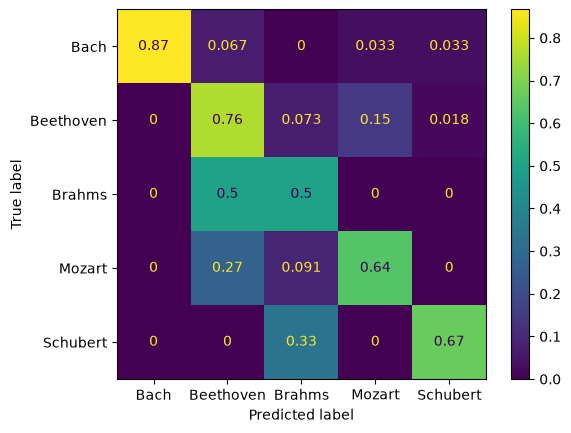

In [ ]:
from sklearn import preprocessing
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

param_grid = {
    "C": [10 ** i for i in range(-1, 3)],
    "gamma": [0.001, 0.005, 0.01, 0.1]
}

svm_model = make_pipeline(
    StandardScaler(),
    SVC(
        kernel = 'rbf',
        class_weight = None
    )
)

_ = run_classical_train_pipeline(
    "svm_midi",
    X=X_midi,
    y=y_midi, 
    groups=groups_midi, 
    model=svm_model, 
    cv=sgkf, 
    param_grid=param_grid, 
    outer_cv=sgkf_outer
)

---

## XGBoost

Gradient boosting ansambl — stabla se dodaju sekvencijalno, svako ispravlja greške prethodnih. Često
nadmaši Random Forest na ovakvim tabelarnim feature setovima. `LabelEncoder` je potreban jer XGBoost
očekuje numeričke labele, ne stringove.

: accuracy=0.8239, macro_f1=0.6440

Best params: {}
Best accuracy: 0.8238505747126437
Best macro F1: 0.6440270146520146 

              precision    recall  f1-score   support

        Bach       1.00      0.90      0.95        30
   Beethoven       0.80      0.95      0.87        55
      Brahms       0.60      0.38      0.46         8
      Mozart       0.56      0.45      0.50        11
    Schubert       0.86      0.67      0.75         9

    accuracy                           0.82       113
   macro avg       0.76      0.67      0.71       113
weighted avg       0.82      0.82      0.81       113

Overall work accuracy: 0.8230088495575221
Overall work macro F1: 0.705114709851552


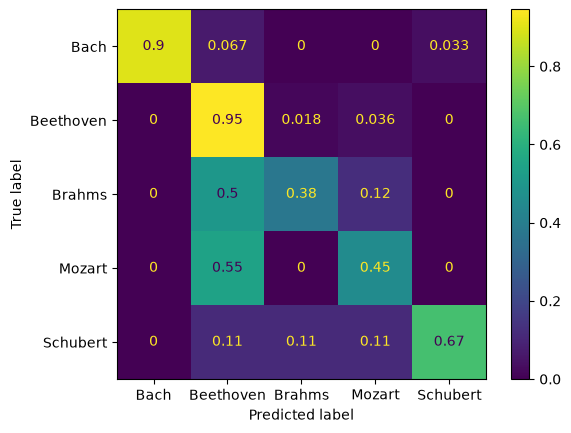

In [ ]:
from xgboost import XGBClassifier
from sklearn import preprocessing
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

xgb_model = XGBClassifier(
    n_estimators=400,
    max_depth=5,
    learning_rate=0.1,
    eval_metric="mlogloss",
    random_state=42,
    n_jobs=-1
)

_ = run_classical_train_pipeline(
    "xgb_midi",
    X=X_midi,
    y=y_midi, 
    groups=groups_midi, 
    model=xgb_model, 
    cv=sgkf, 
    label_encode=True
    # param_grid=param_grid, 
    # outer_cv=sgkf_outer
)